<a href="https://colab.research.google.com/github/alessandronascimento/Bioestatistics/blob/main/Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normal Curve #


Let's use some function from [scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm) to work with properties of a normal curve.

In [1]:
#@title Import libraries & integration function (cdf - cumulative distribution function)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


# Define a function to calculate the area between two Z-scores
def calculate_area_under_gaussian(z_lower, z_upper, mu=0, sigma=1):
    """
    Calculates the area under a Gaussian (Normal) curve between two Z-scores.

    Args:
        z_lower (float): The lower Z-score (or x-value).
        z_upper (float): The upper Z-score (or x-value).
        mu (float): The mean of the normal distribution (default is 0 for standard normal).
        sigma (float): The standard deviation of the normal distribution (default is 1 for standard normal).

    Returns:
        float: The area under the curve between z_lower and z_upper.
    """
    if z_lower >= z_upper:
        return 0.0
    return norm.cdf(z_upper, loc=mu, scale=sigma) - norm.cdf(z_lower, loc=mu, scale=sigma)

In [ ]:
#@title Plot a standard normal curve

# Define the parameters for a standard normal distribution
mu = 0  #@param {"type":"number"}
sigma = 1 #@param {"type":"number"}

# Generate x-values for the plot
x = np.linspace(mu - 10*sigma, mu + 10*sigma, 500)

# Calculate the probability density function (PDF) for each x-value
pdf_values = norm.pdf(x, mu, sigma)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, pdf_values, color='blue', linewidth=2, label='Standard Normal PDF')

# Add title and labels
ax.set_title('Standard Gaussian (Normal) Distribution', fontsize=16)
ax.set_xlabel('Z-score (Number of Standard Deviations from Mean)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend()
plt.show()

## Normal curve
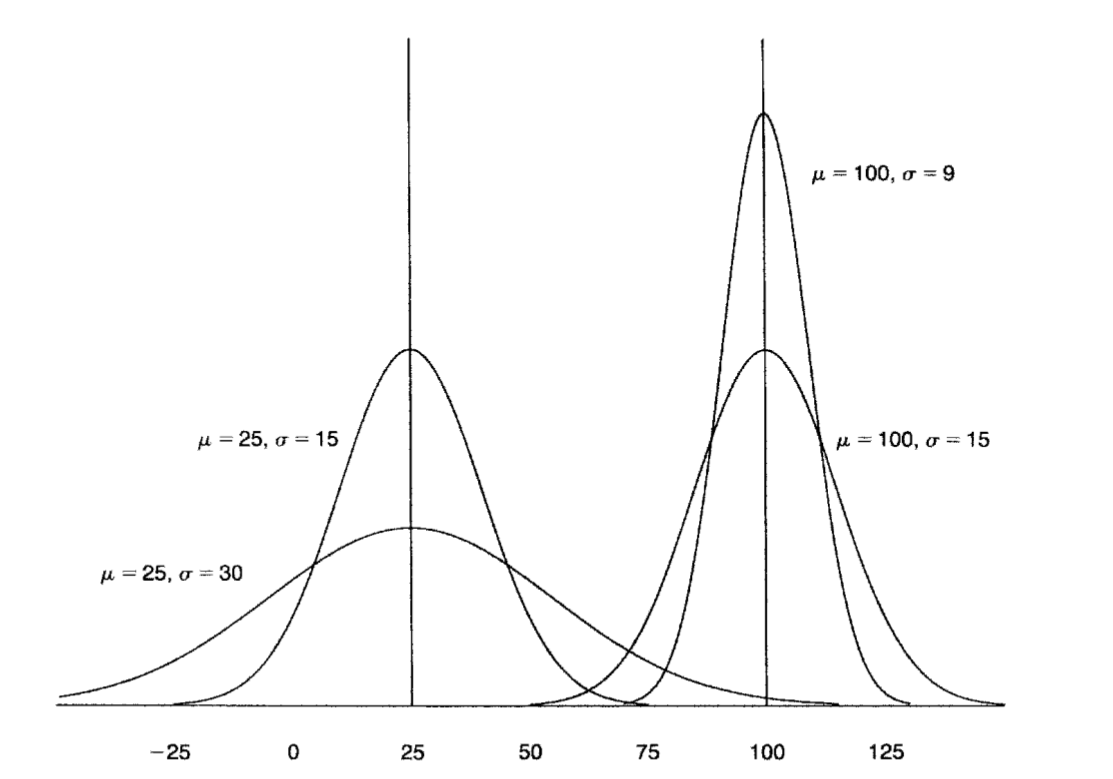

### Calculating Area Under the Curve for Arbitrary Intervals (Online Integration)

To calculate the area under the Gaussian curve between any two points, we can leverage the Cumulative Distribution Function (CDF). The CDF, denoted \\( F(x) \\), gives the probability that a random variable \\( X \\) will take a value less than or equal to \\( x \\).


The area between two points \\( a \\) and \\( b \\) (where \\( a < b \\)) is then simply \\( F(b) - F(a) \\).


In [ ]:
#@title Compute a Standard Normal Distribution Area Table

# Define the intervals for integration

custom_intervals = []


# 15 data points in 0.25 steps (0, 0.25, 0.5, ...)

for i in range(0, 15):
  custom_intervals.append((-10, i*0.25))

# Create a list to store results for the table
results = []

for lower, upper in custom_intervals:
    area = calculate_area_under_gaussian(lower, upper)
    results.append({
        'Lower Bound (Z)': lower,
        'Upper Bound (Z)': upper,
        'P[Z < z]': f'{area:.4f}',
        'P[Z > z]': f'{1-area:.4f}'
    })

# Create a Pandas DataFrame to display the results
custom_area_df = pd.DataFrame(results)
display(custom_area_df)


## Dealing with AUC for the normal curve

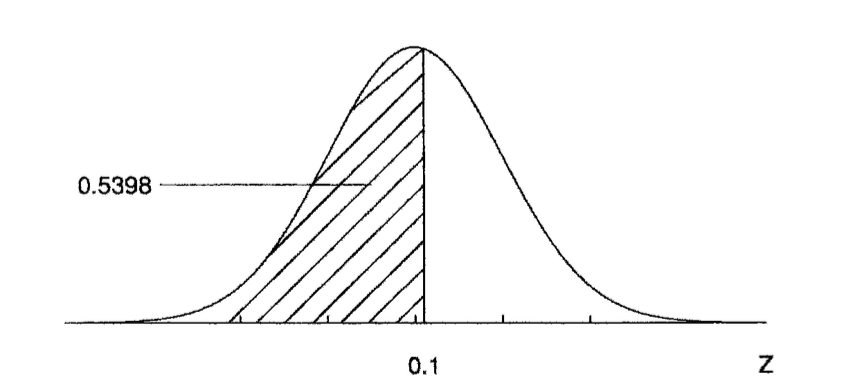

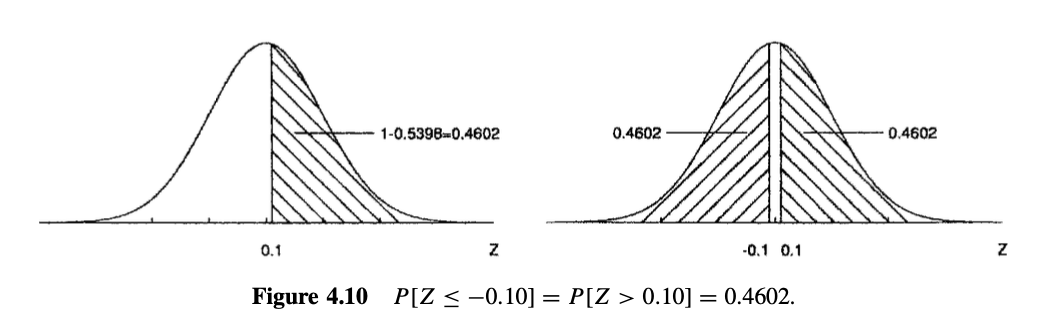

In [ ]:
#@title Compute the area/probability for any value

lower = -10 #@param {"type":"number"}
upper = 1.0 #@param {"type":"number"}
prob = calculate_area_under_gaussian(lower, upper)
print(f'P[Z < {upper:.3f}] = {prob:.4f}')
print(f'P[Z > {upper:.3f}] = {1-prob:.4f}')

# Dealing with probabilities in the Normal model

### Example 1


Suppose that IQ is normally distributed with mean μ = 100 and standard deviation σ = 15. A person with IQ > 115 has a high IQ.

**What proportion of the population has high IQs?**


### Solution

It is clear that IQ = 115 is one standard deviation above the mean, so the statement $P [IQ > 115]$ is equivalent to $P [Z > 1]$:

$
Z_{IQ} = \frac{115-\mu}{\sigma} = \frac{115-100}{15} = 1
$


$P[Z>1]=0.1587$, thus, 15.87% of the population has a high IQ. By the same token, if an IQ below 85 is labeled low IQ, 15.87% of the population has a low IQ.

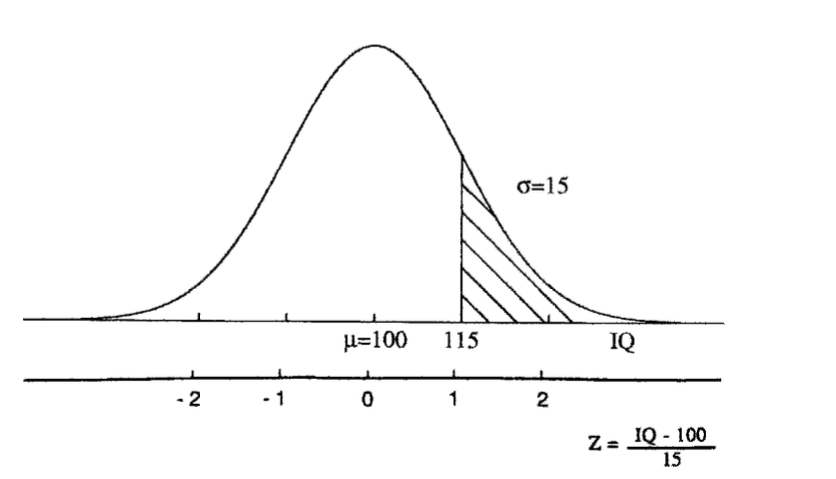

# Dealing with probabilities in the Normal model

### Example 2


Consider the serum cholesterol levels of Wisconsin children as shown before. Suppose that the population **mean is 175 mg per 100 mL and the population standard deviation is 30 mg per 100 mL**.

Suppose that a “*normal cholesterol value*” is taken to be a value within **two** standard deviations of the mean.

1. **What are the normal limits, and **
2. **What proportion of population will be within normal limits?**


### Solution

First we need to know the area/probability of being $P[-2 < Z < 2]$. This is the same as $ 1 - (2 \times P[Z > 2])$ as shown below:

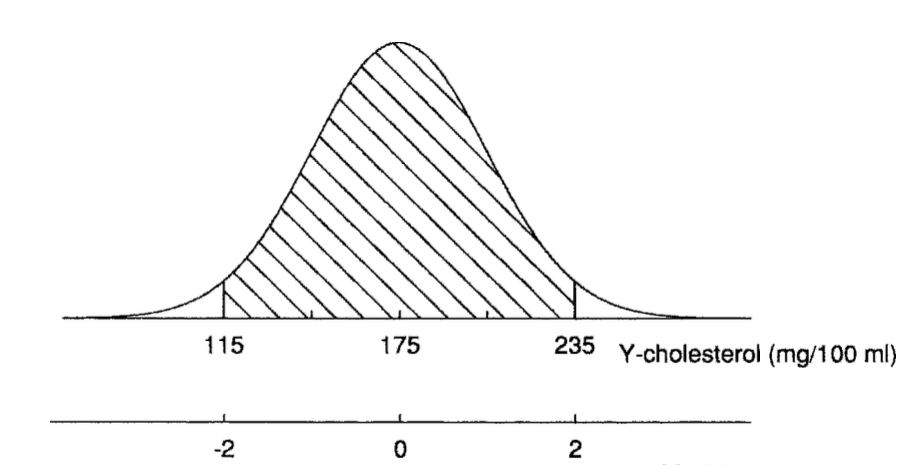

$P[Z>2] = 0.0228$, so, the tails of the distribution account for 0.0456 in area.

The reamining area will be $1 - 0.0456 = 0.9544$. So, we expect 95.44% of the population to have cholesterol levels within the "normal" limits.

Now, what are the normal limits?


If

$
Z = \frac{Y-\mu}{\sigma}
$

Then,

$
Y = \sigma Z + \mu
$

In our case:

$Y = 30*2 + 175 = 235$

$Y = 30*(-2) + 175 = 115 $

So, the normal levels would be between 115 and 235 mg per 100 mL.



## Final Example ##

For the cholesterol level, suppose that instead of defining normal limits and calculating the proportion within these limits, we define the limits such that, say, 95% of the population has cholesterol values within the stated limits.


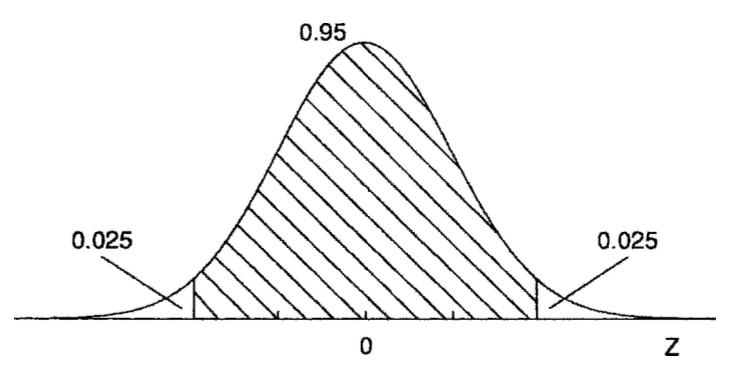

### Solution


So, we need to find the Z-value that sums 95% of the area under the curve with $P[-Z<z<+2]$.

In practical terms, we want to find *z* for which $P[Z<z]=0.975$.

Our table suggests that it should be somewhere between Z=1.75 and Z=2.0, but closer to 2.0 than to 1.75.



If 1.96 does the job, we can compute the normal limits again:

$
Y = \sigma Z + \mu
$

$Y = 30(1.96) + 175 = 234$

$Y = 30(-1.96) + 175 = 116$


So, 95% of the population should have cholesterol levels between 116 and 234 mg per 100 mL.